In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/upload_1cc29b48-7982-4cdb-a0c8-c647c3cd2aa1.csv")
df

In [ ]:
df2=df.iloc[:,13:23]
df2


In [ ]:
X = df2.drop('tempo', axis=1)
y = df2['tempo']

In [ ]:
null_count=df2.isnull().sum()
null_count

In [ ]:
corr = df2.corr()
sns.heatmap(corr)
plt.figure(figsize=(12,8))
plt.title('Correlation Matrix of Audio Features')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df2)
scaled_data

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
df2['Cluster'] = clusters
df2.head()
centers = kmeans.cluster_centers_

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df2['tempo'],
    df2['valence'],
    c=df2['Cluster']
)

plt.xlabel("Tempo")
plt.ylabel("Valence")
plt.title("Spotify Song Clusters")

plt.show()


In [ ]:
sns.countplot(x='Cluster', data=df2)

plt.title("Songs in Each Cluster")
plt.show()

In [ ]:
df2.groupby('Cluster').mean()

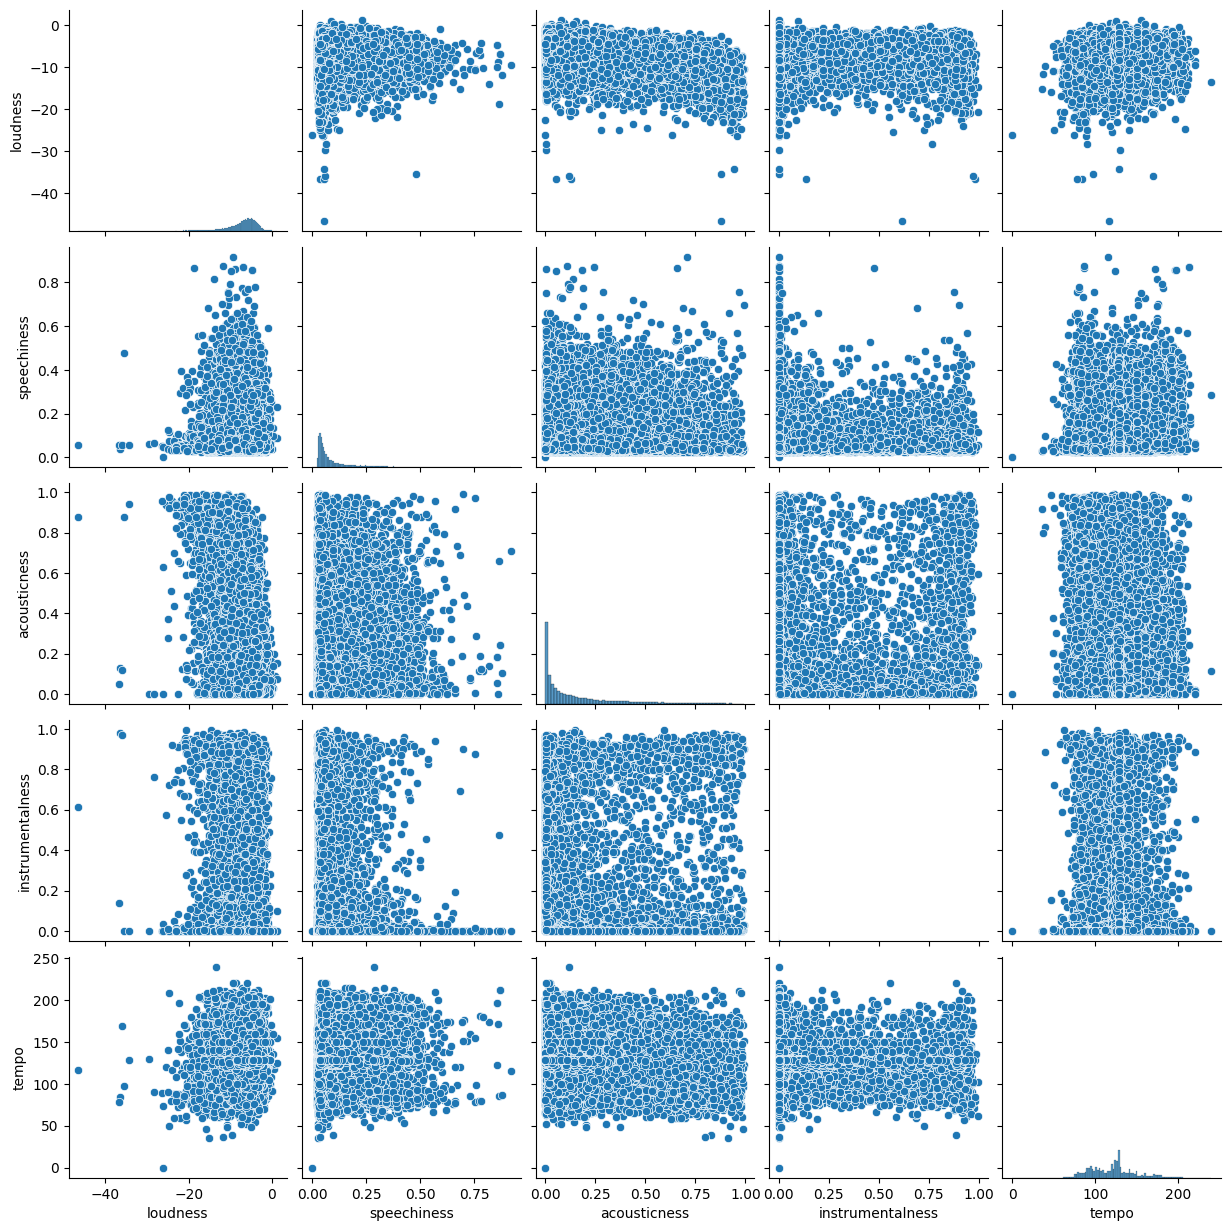

In [12]:
sns.pairplot(df2[['loudness','speechiness','acousticness','instrumentalness','tempo']])
plt.show()

In [13]:
X = df2.drop('tempo', axis=1)
y = df2['tempo']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

In [ ]:
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_test, pred):

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)

    return mae, mse, rmse

In [ ]:
lr_results = evaluate(y_test, lr_pred)
dt_results = evaluate(y_test, dt_pred)
rf_results = evaluate(y_test, rf_pred)

print("Linear Regression:", lr_results)
print("Decision Tree:", dt_results)
print("Random Forest:", rf_results)

In [ ]:
tempo_index = df2.columns.get_loc('tempo')
kmeans_pred = []

for c in clusters:
    kmeans_pred.append(centers[c][tempo_index])
kmeans_pred = np.array(kmeans_pred)

In [ ]:
kmeans_rmse = np.sqrt(mean_squared_error(df2['tempo'], kmeans_pred))
print("KMeans RMSE:", kmeans_rmse)

In [ ]:
models = {
    "Linear Regression": lr_results[2],
    "Decision Tree": dt_results[2],
    "Random Forest": rf_results[2],
    "KMeans": kmeans_rmse
}

best_model = min(models, key=models.get)

print("Best Model:", best_model)
print("Lowest RMSE:", models[best_model])

In [ ]:
names = list(models.keys())
values = list(models.values())

plt.figure(figsize=(8,5))

plt.bar(names, values)

plt.title("Model Comparison (RMSE)")
plt.xlabel("Algorithms")
plt.ylabel("RMSE")

for i, v in enumerate(values):
    plt.text(i, v + 0.5, round(v,2), ha='center')

plt.show()